# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Mayadi Alamsyah Putra Silalahi
- **Email:** mayadisilalahi@gmail.com
- **ID Dicoding:** mayadi21

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penjualan dan revenue E-commerce dalam 12 bulan terakhir?
- Produk apa saja yang paling banyak dan paling sedikit terjual?
- Kapan terakhir pelanggan melakukan transaksi?
- Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir?
- Berapa banyak uang yang dihabiskan pelanggan dalam beberapa bulan terakhir? 

## Import Semua Packages/Library yang Digunakan

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


## Data Wrangling

### Gathering Data

#### Load tabel customers

In [88]:


customers_df = pd.read_csv("data/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Load tabel geolocation

In [89]:
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


#### Load tabel order items

In [90]:
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load tabel order payments

In [91]:
payments_df = pd.read_csv("data/order_payments_dataset.csv")
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Load tabel order reviews

In [92]:
reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#### Load tabel order

In [93]:
orders_df = pd.read_csv("data/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load tabel product

In [94]:
products_df = pd.read_csv("data/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Load tabel product category name translation

In [95]:
product_translation_df = pd.read_csv("data/product_category_name_translation.csv")
product_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


#### Load tabel sellers

In [96]:
sellers_df = pd.read_csv("data/sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Terdapat 9 tabel yang berhasil dimuat dalam dataset ini.
<br> <br>

| No | Nama Dataset                          | Deskripsi                                                                 |
|----|--------------------------------------|---------------------------------------------------------------------------|
| 1  | customers_dataset.csv                | Berisi informasi tentang identitas dan lokasi pelanggan                  |
| 2  | geolocation_dataset.csv              | Berisi data pemetaan wilayah dan geografis                               |
| 3  | order_items_dataset.csv              | Berisi detail item barang dalam setiap pesanan                           |
| 4  | order_payments_dataset.csv           | Berisi informasi metode pembayaran yang digunakan pelanggan              |
| 5  | order_reviews_dataset.csv            | Berisi data umpan balik atau ulasan dari pelanggan                       |
| 6  | orders_dataset.csv                   | Berisi informasi utama terkait pesanan (order)                           |
| 7  | products_dataset.csv                 | Berisi spesifikasi fisik dan kategori produk                             |
| 8  | sellers_dataset.csv                  | Berisi informasi mengenai penjual di e-commerce                          |
| 9  | product_category_name_translation.csv| Berisi terjemahan kategori produk dalam bahasa Inggris                   |


Dataset ini memiliki rentang waktu sekitar dari **September 2016** sampai **Oktober 2018**

### Assessing Data

#### Menilai dan mengidentifikasi data customers_df

In [97]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [98]:
print("Jumlah data duplikat: ", customers_df.duplicated().sum())
customers_df.describe(include="all")

Jumlah data duplikat:  0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Insight:**
- tidak ada missing value dan tidak ada data duplikat dalam dataset ini.
- Data type pada column `customer_zip_code_prefix` adalah integer. Akan lebih baik jika data type nya diubah menjadi object mengingat column ini adalah kategori data wilayah.

#### Menilai dan mengidentifikasi data geolocation_df

In [99]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [100]:
print("Jumlah data duplikat: ", geolocation_df.duplicated().sum())
geolocation_df.describe(include="all")

Jumlah data duplikat:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


**Insight:**
- Tidak ada masalah nilai null.
- Dataset ini memiliki banyak data duplikat yang harus ditangani.
- Tipe data `geolocation_zip_code_prefix` pada dataset ini sebaiknya diubah menjadi *object*.

#### Menilai dan mengidentifikasi data order_items_df

In [101]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [102]:
print("Jumlah data order_items_df duplikat: ", order_items_df.duplicated().sum())
order_items_df.describe(include="all")

Jumlah data order_items_df duplikat:  0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


**Insight:**
- Tidak ada masalah missing value dan duplicate.
- Jika diperhatikan, seharusnya data type pada column `shipping_limit_date` adalah *datetime*, bukan *object*.

#### Menilai dan mengidentifikasi data payments_df

In [103]:
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [104]:
print("Jumlah data payments_df duplikat: ", payments_df.duplicated().sum())
payments_df.describe(include="all")

Jumlah data payments_df duplikat:  0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


**Insight :**
- Tidak ada nilai null dan tidak ada data yang duplikat dalam dataset ini.
- Dari describe secara statistik sederhana, juga belum ditemukan masalah dan tipe data setiap kolom sudah sesuai.

#### Menilai dan mengidentifikasi data reviews_df

In [105]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [106]:
reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [107]:
print("Jumlah data reviews_df duplikat: ", reviews_df.duplicated().sum())
reviews_df.describe(include="all")

Jumlah data reviews_df duplikat:  0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,08528f70f579f0c830189efc523d2182,df56136b8031ecd28e200bb18e6ddb2e,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


**Insight:**
- Sebagian besar data pada column `review_comment_title` dan `review_comment_message` memiliki missing value.
- Terdapat kesalahan tipe data pada column `review_creation_date` dan `review_answer_timestamp` yang seharusnya adalah *datetime*
- Tidak ada data yang duplikat.

#### Menilai dan mengidentifikasi data orders_df

In [108]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [109]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [110]:
print("Jumlah data orders_df duplikat: ", orders_df.duplicated().sum())
orders_df.describe(include="all")

Jumlah data orders_df duplikat:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Dapat diperhatikan bahwa column order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date memiliki missing value.
- Terdapat juga 5 column yang memiliki kesalahan tipe data, yaitu `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`.


#### Menilai dan mengidentifikasi data products_df

In [111]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [112]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [113]:
print("Jumlah data products_df duplikat: ", products_df.duplicated().sum())
products_df.describe(include="all")

Jumlah data products_df duplikat:  0


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


**Insight:**
- Selain pada column `product_id`, column pada dataset ini memiliki missing value dan tidak ada data duplikat yang terdeteksi.

#### Menilai dan mengidentifikasi data product_translation_df

In [114]:
product_translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [115]:
print("Jumlah data product_translation_df duplikat: ", product_translation_df.duplicated().sum())
product_translation_df.describe(include="all")

Jumlah data product_translation_df duplikat:  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**
- Pada dataset ini tidak ada masalah yang berarti. Tidak ada missing value dan data duplikat yang ditemukan.

#### Menilai dan mengidentifikasi data sellers_df

In [116]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [117]:
print("Jumlah data sellers_df duplikat: ", sellers_df.duplicated().sum())
sellers_df.describe(include="all")

Jumlah data sellers_df duplikat:  0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


**Insight:**
- Tidak ada missing value yang ditemukan dan tidak ada data duplikat.
- Column `seller_zip_code_prefix` juga memiliki kesalahan tipe data karena bertujuan untuk menunjukkan kode wilayah.

### Cleaning Data

#### Membersihkan data customers_df

Pada data customers_df ini, masalah ataupun yang saya temukan adalah kesalahan tipe data pada column customer_zip_code_prefix. Lebih baik diubah ke object

In [118]:
customers_df.customer_zip_code_prefix = customers_df.customer_zip_code_prefix.astype("object")

In [119]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


#### Membersihkan data geolocation_df

Pada data geolocation, tindakan yang dilakukan adalah menghapus data duplikat dan mengubah tipe data dari column geolocation_zip_code_prefix

In [120]:
geolocation_df.drop_duplicates(inplace=True)

print("Jumlah data geolocation_df duplikat: ", geolocation_df.duplicated().sum())

Jumlah data geolocation_df duplikat:  0


In [121]:
geolocation_df.geolocation_zip_code_prefix = geolocation_df.geolocation_zip_code_prefix.astype("object")

In [122]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  object 
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), object(3)
memory usage: 33.8+ MB


#### Membersihkan data order_items_df

Kesalahan tipe data pada column shipping_limit_date akan diperbaiki dan diubah menjadi *datetime datatype*

In [123]:
order_items_df.shipping_limit_date = pd.to_datetime(order_items_df.shipping_limit_date)

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### Membersihkan data reviews_df

Tindakan yang dilakukan adalah menangani missing value pada column review_comment_title dan review_comment_message. Kemudian, tipe data pada column review_creation_date review_answer_timestamp akan diperbaiki

**Menangani missing value**

In [124]:
na_comment = ["review_comment_title","review_comment_message"]

for col in na_comment:
  reviews_df[col].fillna(value = "NO COMMENT", inplace=True)

**Menangani kesalahan tipe data**

In [125]:
col_date = ["review_creation_date", "review_answer_timestamp"]

for col in col_date:
  reviews_df[col] = pd.to_datetime(reviews_df[col])

In [126]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


#### Membersihkan data orders_df

Pada tahap assesing data orders_df, didapat ada 5 kolom yang memiliki kesalahan tipe data. Kolom-kolom tersebut berkaitan dengan waktu dan tanggal sehingga seharusnya diberi data type datetime.

Selain itu, ditemukan adanya 3 kolom yaitu `order_approved_at`, `order_delivered_carrier_date`,  dan `order_delivered_customer_date` yang memiliki missing values. 
Untuk ketiga kolom tersebut, saya akan tetap membiarkannya karena nilai null menjadi pilihan terbaik ketika menganalisis performa pengiriman nantinya.

Khusus penanganan untuk column `order_delivered_customer_date` (kolom yang menunjukan waktu barang sampai ke tangan customer), akan lebih baik membuat satu kolom baru yaitu *`is_delivered`* untuk mengetahui apakah barangnya sampai ke customer atau tidak.

**Mengubah tipe data pada kolom yang berkaitan dengan waktu**

In [127]:
col_date = ["order_purchase_timestamp", 
            "order_approved_at", 
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            ]

for col in col_date:
  orders_df[col] = pd.to_datetime(orders_df[col])

In [128]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Menambahkan kolom penjelas ``is_delivered``**

In [129]:

orders_df['is_delivered'] = orders_df['order_delivered_customer_date'].notna()

In [130]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered
53320,779f93413b806f6eea6d1d88053f9e4f,b7fa366f14d8a66cc1b3a514c9200a0a,delivered,2018-07-21 13:54:34,2018-07-21 14:10:11,2018-07-24 15:18:00,2018-07-27 19:37:50,2018-08-06,True
46175,cd1a20782013109d1ec8320dff14d666,7196e7b72271a04057e5ec119b45947e,delivered,2017-11-24 15:48:12,2017-11-25 05:35:18,2017-11-29 22:57:49,2017-12-04 16:49:52,2017-12-18,True
49400,04f2e46bdb0ab9fb67a417100fb3ca71,ce8e936f636f55678640360ddaa0adea,delivered,2017-10-06 00:03:50,2017-10-10 04:14:47,2017-10-11 19:12:44,2017-10-18 21:15:48,2017-10-31,True
28892,2e2005a55f448272a7f91f8ec48db9ee,de3f106541e9cf42f36a02b78a4ecc5b,delivered,2018-05-15 17:07:39,2018-05-15 17:37:28,2018-05-16 14:14:00,2018-06-02 02:41:55,2018-06-07,True
5346,f41b642bbc6b114869453f29da96d041,9eab014e2646490a4e86bf382c50f4bc,delivered,2017-09-07 21:52:13,2017-09-09 05:15:19,2017-09-12 21:08:43,2017-09-23 14:32:42,2017-10-05,True


Column `is_delivered` berupa boolean yang akan bernilai **True** jika pesanan berhasil dikirimkan ke customer, dan bernilai **False** jika tidak sampai ke tangan customer

#### Membersihkan data products_df

Selain pada column `product_id`, semua column pada dataset ini memiliki missing value. Penanganan yang dapat dilakukan pada column `product_category_name` adalah mengisi nilai null dengan **"Undefined Category"**. Untuk kolom lainnya, nilai null tetap dibiarkan guna menjaga integritas data fisik dan menghindari bias statistik, karena mengisi data teknis seperti berat atau dimensi dengan nilai rata-rata berisiko menciptakan informasi semu yang menyesatkan analisis logistik

In [131]:
products_df["product_category_name"].fillna(value="Undifined Category", inplace=True)

In [132]:
products_df.isna().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

#### Membersihkan data sellers_df

Penanganan yang dapat dilakukan pada column `seller_zip_code_prefix` adalah mengubah tipe data nya menjadi *object*

In [133]:
sellers_df.seller_zip_code_prefix = sellers_df.seller_zip_code_prefix.astype("object")

In [134]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   object
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


**Insight :**

Proses cleaning data yang telah dilakukan antara lain:

Pada data `customers_df`, dilakukan perubahan tipe data pada column `customer_zip_code_prefix` ke type data *object*

Pada data `geolocation_df`, tindakan yang dilakukan adalah menghapus data duplikat dan mengubah tipe data dari column `geolocation_zip_code_prefix`

Pada `order_items_df`, tipe data column `shipping_limit_date` diperbaiki dan diubah menjadi *datetime*

Tindakan yang dilakukan pada `reviews_df` adalah menangani missing value pada column `review_comment_title` dan `review_comment_message` dengan mengisi nilai **"NO COMMENT"**. Kemudian, tipe data pada column `review_creation_date` dan `review_answer_timestamp` diperbaiki menjadi *datetime*.

Pada `orders_df`, cleaning yang dilakukan adalah mengubah tipe data pada 5 kolom yang memiliki kesalahan tipe data menjadi *datetime*.Kemudian, melakukan penambahan column `is_delivered` untuk memperjelas apakah pesanan sampai ke pelanggan atau tidak.

Pada `products_df`, penanganan yang telah dilakukan pada column `product_category_name` adalah mengisi nilai null dengan **"Undefined Category"**. Untuk kolom lainnya, nilai null tetap dibiarkan guna menjaga integritas data fisik dagar tidak menyesatkan analisis produk nantinya.

Penanganan yang telah dilakukan pada `sellers_df` adalah mengubah tipe data column `seller_zip_code_prefix` menjadi *object*

## Exploratory Data Analysis (EDA)

### Explore customers_df

In [135]:
customers_df.sample()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
73948,d0a96174092cc6ef4f7671d3bc8c6bf4,f17157bff18a06db593ed76323701583,59022,natal,RN


**Melihat persebaran customer pada setiap negara bagian**

In [136]:
customers_df.groupby(by="customer_state").agg({
    "customer_unique_id": "nunique"
}).sort_values(by="customer_unique_id", ascending=False)

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


Berdasarkan pivot table di atas, distribusi pelanggan banyak terdapat di state SP dengan jumlah pelanggan yang jauh lebih tinggi dibanding wilayah lain, diikuti oleh RJ dan MG. Sementara itu, state dengan angka rendah seperti RR dan AP mengindikasikan potensi pasar yang masih belum maksimal.

**Melihat persebaran customer pada setiap negara bagian**

In [137]:
customers_df.groupby(by="customer_city").agg({
    "customer_unique_id": "count",
}).sort_values(by="customer_unique_id", ascending=False)

,customer_unique_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
agisse,1
vieiras,1
bertopolis,1


Sama seperti eksplorasi sebelumnya pada negara bagian, persebaran customer berdasarkan kota terbanyak dimiliki oleh kota sao paulo, diikuti oleh rio de janeiro dan belo horizonte. Sementara kota seperti abadiania dan xexeu serta beberapa kota serupa masih memiliki satu customer.

### Explore geolocation_df

In [138]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Dapat dilihat bahwa terdapat data duplikat pad kolom `geolocation_zip_code_prefix`. Ke depannya hal tersebut akan sangat menggangu untuk analisis customer. Dan karena saya tidak akan melangkah terlalu jauh dalam analisis geospasial, saya akan menghapus data yang memiliki duplikat pada kolom ini, dan untuk data *latitude* dan *longitude*, akan diisi dengan nilai mean dari setiap nilai duplikat.

In [139]:
geolocation_unique_zip_df = (
    geolocation_df
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': 'first',
        'geolocation_state': 'first'
    })
    .reset_index()
)

In [140]:
geolocation_unique_zip_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550227,-46.634039,sao paulo,SP
1,1002,-23.547657,-46.634991,sao paulo,SP
2,1003,-23.549000,-46.635582,sao paulo,SP
3,1004,-23.549829,-46.634792,sao paulo,SP
4,1005,-23.549547,-46.636406,sao paulo,SP


**Menghitung Sebaran Kode Pos per Negara Bagian**

Kita bisa melihat negara bagian mana yang paling luas secara administratif berdasarkan jumlah zip code

In [141]:
geolocation_unique_zip_df.groupby(by="geolocation_state").agg({
    "geolocation_zip_code_prefix": "nunique",
}).sort_values(by="geolocation_zip_code_prefix", ascending=False)

,geolocation_zip_code_prefix
geolocation_state,
SP,6349
MG,1868
RJ,1390
RS,1131
PR,1046
BA,992
GO,773
SC,619
PE,596


Dari pivot tabel di atas, dapat dilihat bahwa state SP (Sao Paulo) memiliki jumlah zip code dan kota yang jauh lebih tinggi dibanding wilayah lain, disusul oleh MG, RJ, dan RS yang juga memiliki distribusi wilayah cukup luas. Sementara itu, state seperti AP, RR, dan AC memiliki jumlah paling sedikit, menandakan wilayah yang lebih kecil atau tingkat pengembangan yang lebih rendah.

**Menggabungkan dataset customers_df dan sellers_df dengan geolocation_unique_zip_df**

In [142]:
customers_df = customers_df.merge(
    geolocation_unique_zip_df[
        [
            'geolocation_zip_code_prefix',
            'geolocation_lat',
            'geolocation_lng',
            'geolocation_city',
            'geolocation_state'
        ]
    ],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)


customers_df = customers_df.drop(columns=['customer_city', 'customer_state', 'geolocation_zip_code_prefix'])

customers_df = customers_df.rename(columns={
    'geolocation_city': 'customer_city',
    'geolocation_state': 'customer_state',
    'geolocation_lat':'customer_lat',
    'geolocation_lng': 'customer_lng',
})

customers_df.sample()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_lat,customer_lng,customer_city,customer_state
60265,9c4dfe617f87a6b5f13e6a48ec52a5f2,21e2a8d118df3b7ee58f1be9b8cc819e,97105,-29.706288,-53.718477,santa maria,RS


In [143]:
sellers_df = sellers_df.merge(
    geolocation_unique_zip_df[
        [
            'geolocation_zip_code_prefix',
            'geolocation_lat',
            'geolocation_lng',
            'geolocation_city',
            'geolocation_state'
        ]
    ],
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)


sellers_df = sellers_df.drop(columns=['seller_city', 'seller_state', 'geolocation_zip_code_prefix'])

sellers_df = sellers_df.rename(columns={
    'geolocation_city': 'seller_city',
    'geolocation_state': 'seller_state',
    'geolocation_lat':'seller_lat',
    'geolocation_lng': 'seller_lng',
})

sellers_df.sample()


,seller_id,seller_zip_code_prefix,seller_lat,seller_lng,seller_city,seller_state
1790,213b25e6f54661939f11710a6fddb871,13321,-23.191718,-47.290079,salto,SP


Dengan penggabungan di atas, akan lebih mudah melihat data geolocation yang ada dari setiap customer dan seller.


### Explore orders_df

**Analisis Status Pesanan**

In [144]:
orders_df.groupby(by="is_delivered").agg({
    "order_id": "count"
}).sort_values(by="order_id", ascending=False)

,order_id
is_delivered,
True,96476
False,2965


Sebagian besar pesanan telah berhasil diselesaikan dengan status delivered (96.476), menunjukkan performa operasional yang sangat baik. Namun, beberapa pesanan ada yang belum sampai ke tangan customer.

**Analisis waktu approval pesanan dan waktu pengiriman**

In [145]:
orders_df['approval_time'] = (orders_df['order_approved_at'] - orders_df['order_purchase_timestamp']).dt.total_seconds() / 60 # dalam menit

orders_df.agg({
    "approval_time": ["mean", "median"]
})


delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders_df["delivery_time"] = round(delivery_time/86400)

orders_df[["approval_time", "delivery_time"]].describe()

,approval_time,delivery_time
count,99281.000000,96476.000000
mean,625.145658,12.517548
std,1562.280218,9.550516
min,0.000000,1.000000
25%,12.900000,7.000000
50%,20.600000,10.000000
75%,874.850000,16.000000
max,270550.833333,210.000000


Dari pivot table di atas, dapat dilihat bahwa rata-rata waktu pemrosesan pesanan 
sekitar 625 menit (sekitar 10 jam), tetapi median hanya 20 menit, yang menunjukkan distribusi sangat skewed (banyak order cepat diproses, namun ada beberapa yang sangat lama hingga mengganggu rata-rata naik).

Sementara itu, waktu pengiriman rata-rata sekitar 12,5 hari dengan median data 10 hari. Dapat dilihat juga adanya max lama waktu pengiriman selama 210 hari yang menunjukkan adanya ketidak konsistenan pada proses pengiriman.

### Explore products_df

**Menerjemahkan kategori produk**

Untuk memudahkan analisis, product_category_name akan diterjemahkan dari data pada dataset product_translation.

In [146]:
products_df = pd.merge(
    products_df, 
    product_translation_df, 
    on="product_category_name", 
    how="left"
)

products_df["product_category_name_english"].fillna(value="Undifined Category", inplace=True)

products_df = products_df.drop(columns=['product_category_name']).rename(columns={'product_category_name_english': 'product_category_name'})




In [147]:
products_df.groupby(by="product_category_name").agg({
    "product_id": "count"
}).sort_values(by="product_id", ascending=False)

,product_id
product_category_name,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
...,...
tablets_printing_image,9
home_comfort_2,5
fashion_childrens_clothes,5


Dari pivot tabel di atas, produk dengan kategori yang memiliki banyak produk, misalnya kategoru bed_bath_table dan sports_leisure menunjukkan adanya persaingan yang cukup ketat pada kategori tersebut.

Sementara itu, ada kategori produk yang memiliki produk sangat sedikit.

### Explore reviews_df

In [148]:
# Menghitung jumlah setiap skor review
reviews_df.groupby(by="review_score").agg({
    "review_id": "count"
}).rename(columns={"review_id": "count"}).sort_values(by="review_score", ascending=False)



,count
review_score,
5,57328
4,19142
3,8179
2,3151
1,11424


Dari pivot table di atas, dapat dilihat bahwa mayoritas score review pada setiap order didominasi oleh skor 5. Ini menunjukkan sebagian besar customer puas terhadap pelayanan yang dilakukan. Namun, jumlah skor nilai 1 lebih tinggi dari skor menengah menunjukkan adanya beberapa pelanggan yang merasa tidak puas terhadap sebagian order.

### Explore payments_df

In [149]:
payments_df.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value": ["sum", "mean"]
}).sort_values(by=("order_id", "nunique"), ascending=False)

order_id payment_value            
              nunique           sum        mean
payment_type                                   
credit_card     76505   12542084.19  163.319021
boleto          19784    2869361.27  145.034435
voucher          3866     379436.87   65.703354
debit_card       1528     217989.79  142.570170
not_defined         3          0.00    0.000000

Dari pivot table di atas terlihat bahwa metode pembayaran paling dominan adalah credit_card, baik dari jumlah transaksi maupun rata rata nilai pembayaran, yang menunjukkan preferensi utama pelanggan pada metode ini. 

Sementara itu, metode seperti voucher dan debit_card digunakan jauh lebih sedikit, dengan nilai transaksi rata-rata yang juga lebih rendah dibanding credit card dan boleto.

### Explore order_items + products_df


In [150]:
product_sales_df = pd.merge(
    order_items_df, 
    products_df, 
    on="product_id", 
    how="left"
)

product_sales_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


**Analisis revenue kategori produk**

In [151]:
product_sales_df.groupby("product_category_name").agg({
    "order_id": "nunique",      # Volume Pesanan
    "price": "sum",             # Total Revenue
    "product_id": "count"       # Total Item Terjual
}).sort_values(by="price", ascending=False)



,order_id,price,product_id
product_category_name,,,
health_beauty,8836,1258681.34,9670
watches_gifts,5624,1205005.68,5991
bed_bath_table,9417,1036988.68,11115
sports_leisure,7720,988048.97,8641
computers_accessories,6689,911954.32,7827
...,...,...,...
flowers,29,1110.04,33
home_comfort_2,24,760.27,30
cds_dvds_musicals,12,730.00,14


Dari pivot table,terlihat bahwa kategori health_beauty, watches_gifts, dan bed_bath_table memiliki revenue terbesar, yang menunjukkan permintaan tinggi dan performa penjualan yang kuat di kategori tersebut. 

Sebaliknya, kategori seperti fashion_childrens_clothes dan security_and_services memiliki penjualan sangat rendah, sehingga berpotensi menjadi area yang kurang diminati.

**Analisis Biaya Pengiriman berdasarkan Berat Produk**

In [152]:

# Agregasi untuk melihat rata-rata biaya kirim per rentang berat (misal per kg)
product_sales_df.groupby(pd.cut(product_sales_df['product_weight_g'], bins=[0, 1000, 5000, 10000, 20000, 400000])).agg({
    "freight_value": "mean",
    "price": "mean"
})



,freight_value,price
product_weight_g,,
"(0, 1000]",15.810879,88.277219
"(1000, 5000]",20.277637,137.698864
"(5000, 10000]",30.683780,183.728366
"(10000, 20000]",47.480043,293.363400
"(20000, 400000]",89.118910,534.794493


Dari pivot table di atas, terlihat jelas adanya hubungan antara berat produk dengan biaya kirim dan juga harga produk.

Hal ini menunjukkan bahwa ongkos logistik berbanding lurus dengan berat barang, dan produk yang lebih berat cenderung memiliki nilai jual yang lebih tinggi.

### Explore orders_df + customers_df + sellers_df

In [153]:
# 1. Merge orders + customers
orders_customers_df = pd.merge(
    orders_df,
    customers_df,
    on="customer_id",
    how="left"
)

# 2. Merge dengan product_sales
orders_products_df = pd.merge(
    orders_customers_df,
    product_sales_df,
    on="order_id",
    how="left"
)

# 3. Merge dengan sellers
final_df = pd.merge(
    orders_products_df,
    sellers_df,
    on="seller_id",
    how="left"
)

final_df.sample()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,approval_time,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,seller_zip_code_prefix,seller_lat,seller_lng,seller_city,seller_state
25610,48aa82e857be5deaea8efb00a7847b43,8b0b7e9b7100d32941b3cfb34a613b46,delivered,2017-04-10 20:27:44,2017-04-10 20:42:03,2017-05-19 12:27:25,2017-05-23 15:28:00,2017-06-07,True,14.316667,...,1550.0,37.0,23.0,35.0,bed_bath_table,9220,-23.623775,-46.536234,santo andré,SP


**Analisis Seller berdasarkan Total Revenue dan Volume Penjualan**

In [154]:
final_df.groupby("seller_id").agg({
    "price": "sum",
    "order_id": "count",
}).sort_values(by="price", ascending=False)

,price,order_id
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156
53243585a1d6dc2643021fd1853d8905,222776.05,410
4a3ca9315b744ce9f8e9374361493884,200472.92,1987
fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586
7c67e1448b00f6e969d365cea6b010ab,187923.89,1364
...,...,...
34aefe746cd81b7f3b23253ea28bef39,8.00,1
702835e4b785b67a084280efca355756,7.60,1
1fa2d3def6adfa70e58c276bb64fe5bb,6.90,1


Tabel pivot ini menunjukkan bahwa beberapa seller menghasilkan revenue tinggi dengan strategi yang berbeda, dimana terdapat seller dengan jumlah order relatif tidak terlalu tinggi (410) namun nilai transaksinya adalah yang tertinggi kedua. Hal ini mengindikasikan adanya perbedaan positioning, seperti seller yang fokus pada produk premium versus seller yang mengandalkan volume penjualan.

### Menggabungkan semua data

In [155]:
# 2. Tambahkan Data Pembayaran
# Perhatian: Satu order_id bisa punya >1 payment_type (split payment)
final_df = pd.merge(
    final_df,
    payments_df,
    on="order_id",
    how="left"
)

# 3. Tambahkan Data Ulasan (Reviews)
final_df = pd.merge(
    final_df,
    reviews_df,
    on="order_id",
    how="left"
)

# Sekarang final_df kamu sudah lengkap 100%!
final_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,approval_time,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,10.700000,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NO COMMENT,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,10.700000,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NO COMMENT,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,10.700000,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NO COMMENT,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,1842.833333,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,16.566667,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NO COMMENT,NO COMMENT,2018-08-18,2018-08-22 19:07:58


In [156]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   is_delivered                   119143 non-null  bool          
 9   approval_time                  118966 non-null  float64       
 10  delivery_time                  115722 non-null  float64       
 11  

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penjualan dan revenue perusahaan dalam 12 bulan terakhir?

In [157]:
# cari tanggal terakhir di dataset
last_date = final_df['order_purchase_timestamp'].max()

# ambil 12 bulan terakhir
last_12_months_df = final_df[
    final_df['order_purchase_timestamp'] >= (last_date - pd.DateOffset(months=12))
]

monthly_orders_df = last_12_months_df.resample(
    rule='M',
    on='order_purchase_timestamp'
).agg({
    "order_id": "nunique",
    "price": "sum"
})

monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')

monthly_orders_df = monthly_orders_df.reset_index()

monthly_orders_df.rename(columns={
    "order_purchase_timestamp": "order_date",
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

monthly_orders_df.head()

,order_date,order_count,revenue
0,2017-10,2117,314151.01
1,2017-11,7544,1055072.10
2,2017-12,5673,773574.02
3,2018-01,7269,993701.49
4,2018-02,6728,889512.29


In [158]:
monthly_orders_df = last_12_months_df.resample(
    rule='M',
    on='order_purchase_timestamp'
).agg({
    "order_id": "nunique",
    "price": "sum"
})

# format jadi Year-Month
monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')

monthly_orders_df = monthly_orders_df.reset_index()

monthly_orders_df.rename(columns={
    "order_purchase_timestamp": "order_date",
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

monthly_orders_df.head()

,order_date,order_count,revenue
0,2017-10,2117,314151.01
1,2017-11,7544,1055072.10
2,2017-12,5673,773574.02
3,2018-01,7269,993701.49
4,2018-02,6728,889512.29


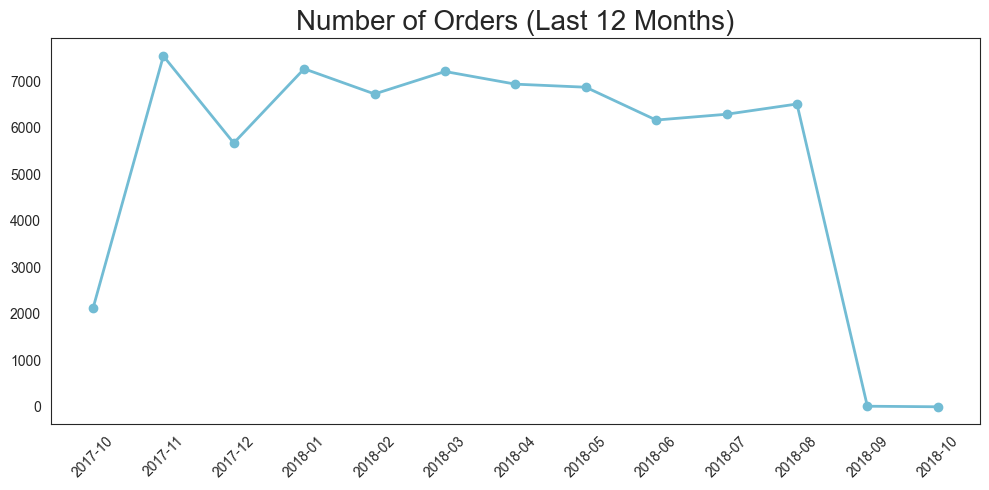

In [159]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_orders_df["order_date"],
    monthly_orders_df["order_count"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Number of Orders (Last 12 Months)", fontsize=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

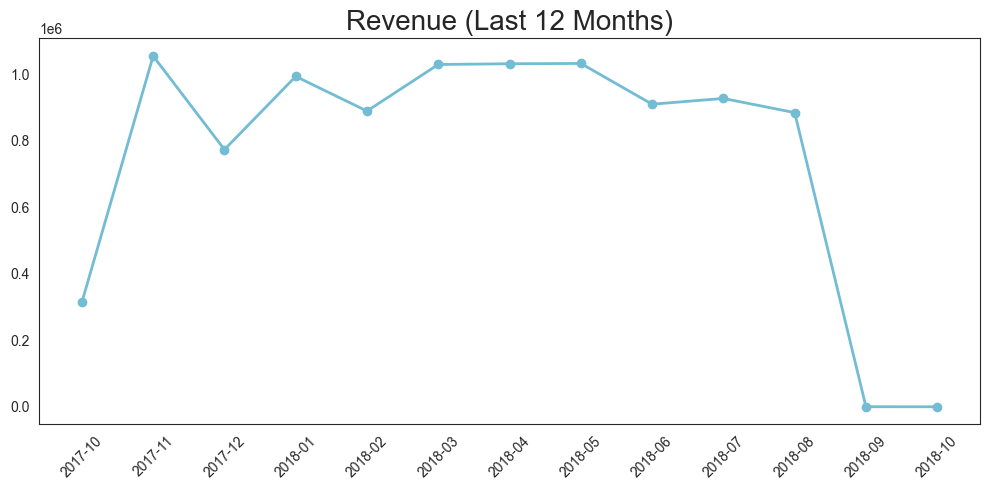

In [160]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_orders_df["order_date"],
    monthly_orders_df["revenue"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Revenue (Last 12 Months)", fontsize=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:

Dari visualisasi jumlah order dan total revenue 12 bulan terakhir di atas, dapat dilihat bahwa adanya lonjakan signifikan pada November 2017, kemudian grafik cukup stabil pada periode sepanjang awal hingga pertengahan 2018.

Mulai pertengahan 2018 terlihat tren penurunan baik pada jumlah order maupun revenue, meskipun masih dalam kisaran yang relatif stabil, kemudian diikuti dengan penurunan drastis pada September–Oktober 2018.

### Pertanyaan 2: Kategori produk Apa yang Paling Banyak dan Paling Sedikit Terjual?

In [161]:
sum_order_items_df = final_df.groupby("product_category_name").agg({
    "order_item_id": "count"
}).rename(columns={
    "order_item_id": "total_sold"
}).sort_values(by="total_sold", ascending=False).reset_index()

sum_order_items_df

,product_category_name,total_sold
0,bed_bath_table,11988
1,health_beauty,10032
2,sports_leisure,9004
3,furniture_decor,8832
4,computers_accessories,8150
...,...,...
67,arts_and_craftmanship,24
68,la_cuisine,16
69,cds_dvds_musicals,14
70,fashion_childrens_clothes,8


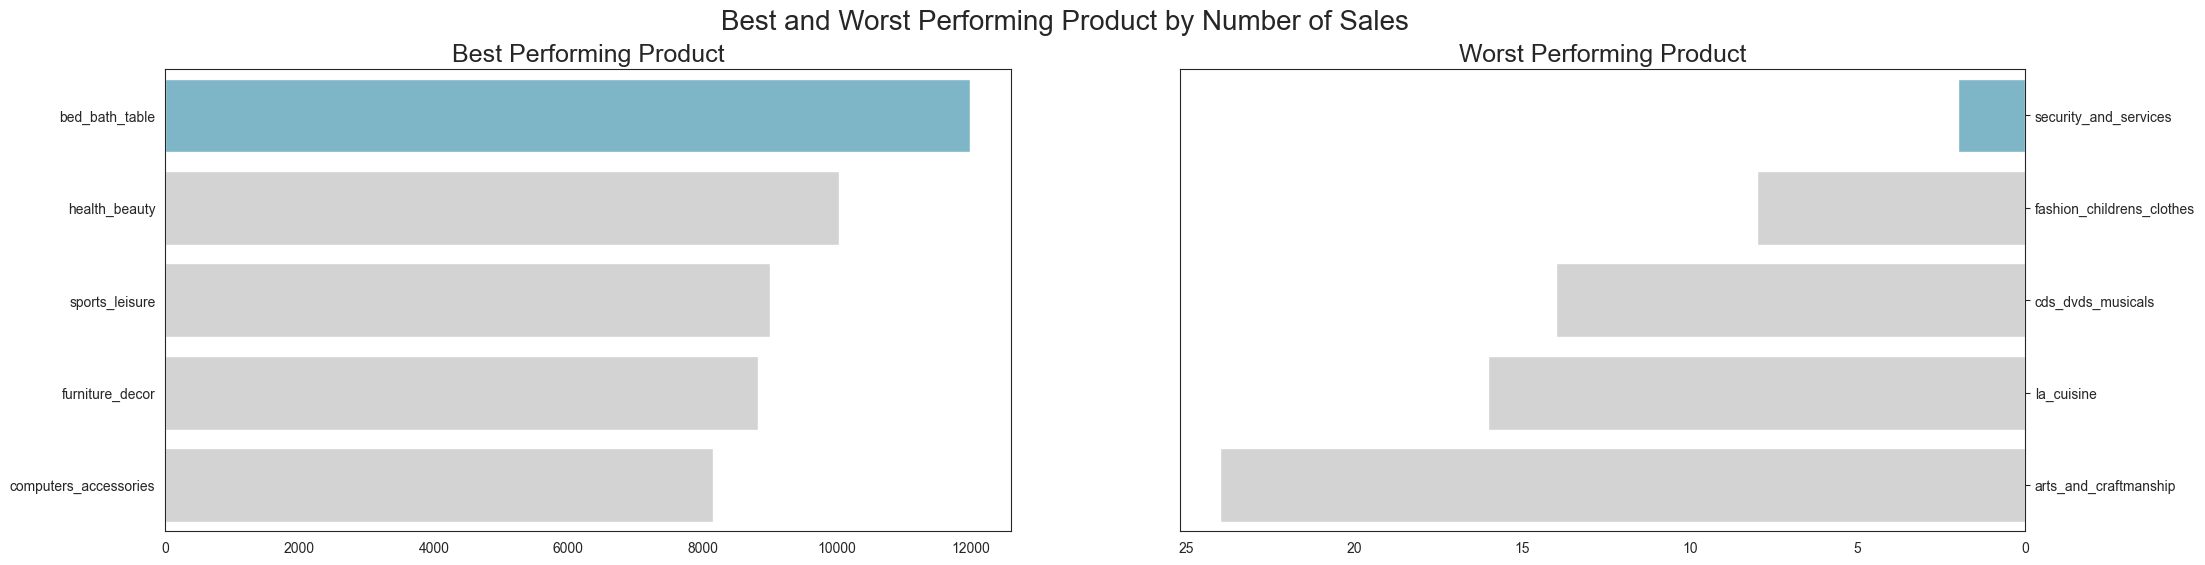

In [162]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4"] + ["#D3D3D3"] * 4

# Best (Top 5)
sns.barplot(
    x="total_sold", 
    y="product_category_name", 
    data=sum_order_items_df.head(5), 
    palette=colors, 
    ax=ax[0]
)

ax[0].set_title("Best Performing Product", fontsize=18)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

# Worst (Bottom 5)
sns.barplot(
    x="total_sold", 
    y="product_category_name", 
    data=sum_order_items_df.sort_values(by="total_sold").head(5), 
    palette=colors, 
    ax=ax[1]
)

ax[1].invert_xaxis()
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", fontsize=18)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

**Insight :**
Dari visualisasi di atas, kageori produk bed_bath_table, health_beauty,dan sports_leisure merupakan kategori produk yang produknya terjual terbanyak.

Sebaliknya, kategori seperti security_and_services dan fashion_childrens_clothes memiliki penjualan paling rendah, yang mengindikasikan demand yang lebih kecil.

## Analisis Lanjutan (Opsional)

### RFM Analysis

In [163]:
final_df.sample()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,approval_time,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
118813,7844d511767a3dbe9411602e49a0ac38,d8045e6cc95ece813867ea4938cf6fa1,delivered,2017-09-03 18:41:07,2017-09-03 18:55:10,2017-09-04 21:47:50,2017-09-11 21:15:19,2017-10-03,True,14.05,...,1.0,credit_card,5.0,77.66,4d93762475df9d01e177844b8ec05f60,5.0,NO COMMENT,"ENTREGA SUPER RÁPIDA, MATERIAL DE ÓTIMA QUALID...",2017-09-12,2017-09-15 03:11:15


**Ubah customer_id menjadi id numerik**

Agar mempermudahkan visualisasi data nantinya, akan lebih baik jika  customer_id (string unik) diubah menjadi integer (ID numerik)

In [164]:
final_df['customer_unique_id_int'] = pd.factorize(final_df['customer_unique_id'])[0] + 1

In [165]:
rfm_df = final_df.groupby(by="customer_unique_id_int", as_index=False).agg({
    "order_purchase_timestamp": "max", # tanggal customer melakukan order terakhir
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_unique_id_int", "max_order_timestamp", "frequency", "monetary"]
rfm_df.head()

,customer_unique_id_int,max_order_timestamp,frequency,monetary
0,1,2017-10-02 10:56:33,2,125.36
1,2,2018-07-24 20:41:37,1,118.70
2,3,2018-08-08 08:38:49,1,159.90
3,4,2017-11-18 19:28:06,1,45.00
4,5,2018-02-13 21:18:39,1,19.90


In [166]:
# menghitung kapan terakhir pelanggan melakukan transaksi (hari)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"]
recent_date = orders_df["order_purchase_timestamp"].dt.date.max()

rfm_df["recency"] = rfm_df["max_order_timestamp"].dt.date.apply(
    lambda x: (recent_date - x).days
)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_unique_id_int,frequency,monetary,recency
0,1,2,125.36,380
1,2,1,118.70,85
2,3,1,159.90,70
3,4,1,45.00,333
4,5,1,19.90,246


In [167]:
rfm_df.describe()

,customer_unique_id_int,frequency,monetary,recency
count,96096.000000,96096.000000,96096.000000,96096.000000
mean,48048.500000,1.034809,148.535836,288.108797
std,27740.670071,0.214384,249.358758,153.417869
min,1.000000,1.000000,0.000000,0.000000
25%,24024.750000,1.000000,47.900000,164.000000
50%,48048.500000,1.000000,89.900000,269.000000
75%,72072.250000,1.000000,159.900000,397.000000
max,96096.000000,17.000000,13440.000000,773.000000


Insight:

Dari deskripsi di atas, dapat dilihat bahwa pelanggan dengan frekuensi pembelian tertinngi adalah sebanyak 17 kali pembelian
Dari segi monetary, kontribusi tertinggi dari satu pelanggan ada di angka 13440 dollar.
Bisa dilihat juga dari pembelian terakhir, rata-rata pelanggan terakhir membeli di 288 hari yang lalu.

In [168]:
rfm_df.sort_values(by="recency", ascending=True).head(5)

,customer_unique_id_int,frequency,monetary,recency
59632,59633,1,0.0,0
66750,66751,2,197.5,1
17993,17994,3,178.0,14
16918,16919,2,65.0,16
49501,49502,1,0.0,18


In [169]:
rfm_df.sort_values(by="frequency", ascending=False).head(5)

,customer_unique_id_int,frequency,monetary,recency
2340,2341,17,729.62,58
3003,3004,9,1000.85,232
16340,16341,7,664.20,111
5287,5288,7,806.61,138
8008,8009,7,855.21,245


In [170]:
rfm_df.sort_values(by="frequency", ascending=False).head(5)

,customer_unique_id_int,frequency,monetary,recency
2340,2341,17,729.62,58
3003,3004,9,1000.85,232
16340,16341,7,664.20,111
5287,5288,7,806.61,138
8008,8009,7,855.21,245


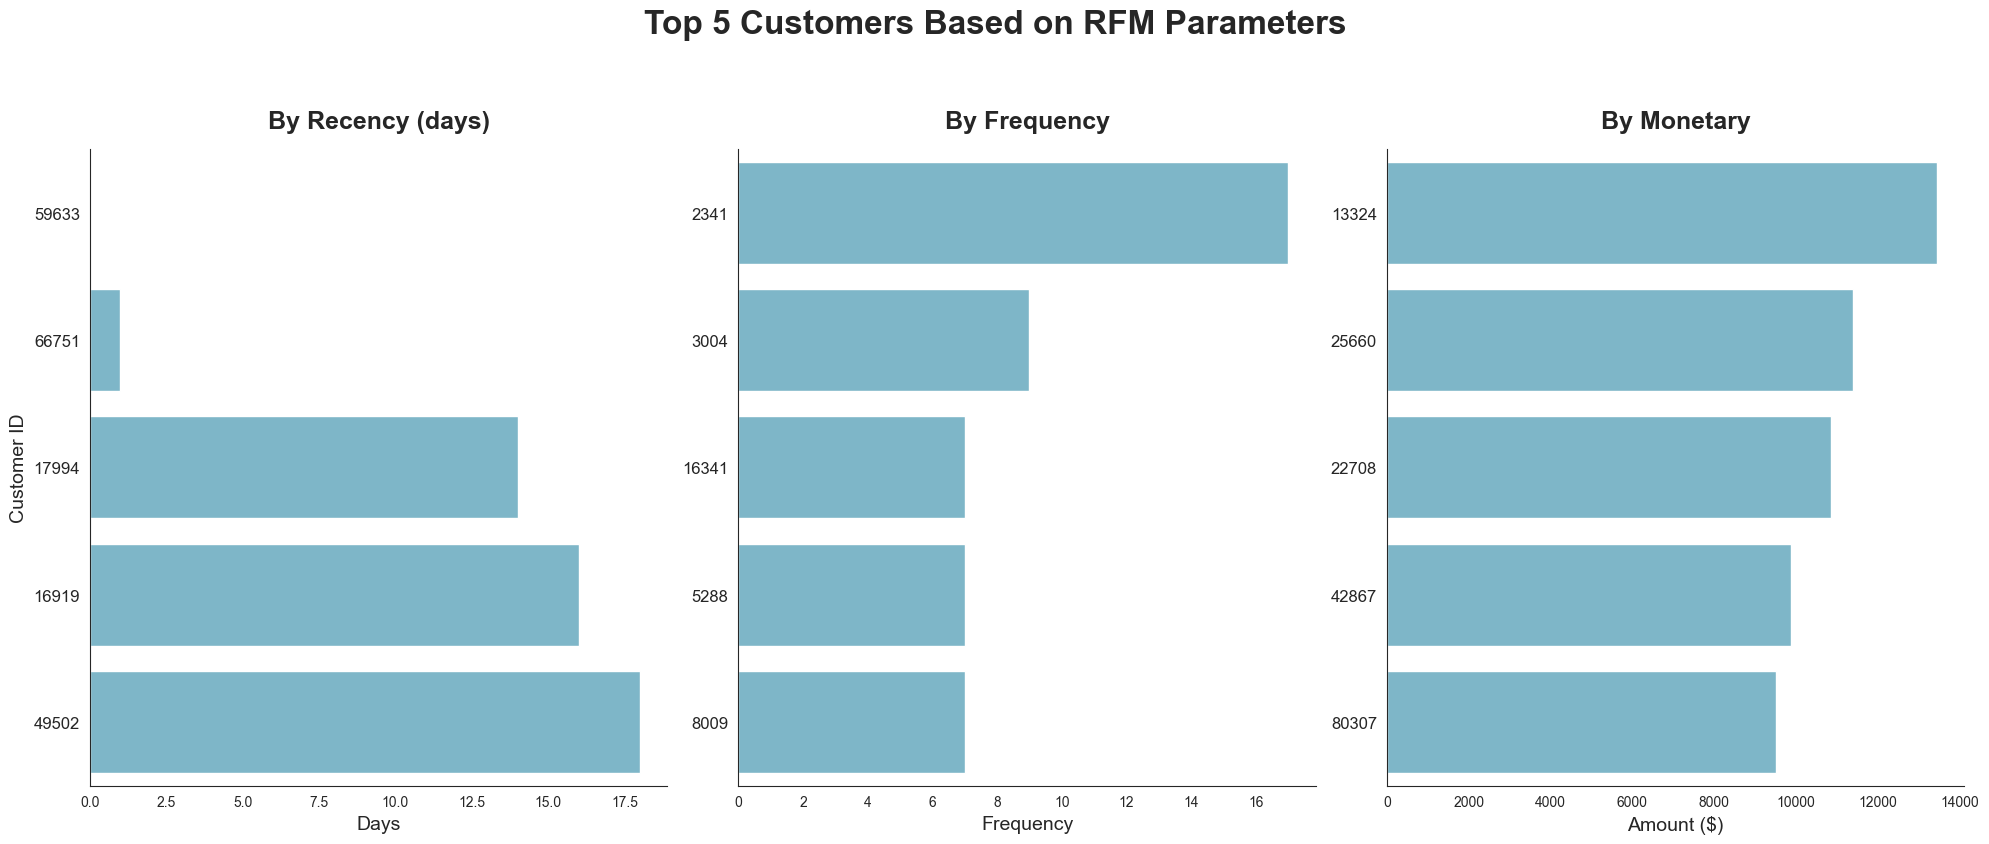

In [171]:
# Set style agar lebih clean
sns.set_style("white")

# Inisialisasi plot
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))
colors = ["#72BCD4"] * 5 

# --- 1. Recency ---
recency_data = rfm_df.sort_values(by="recency", ascending=True).head(5)
sns.barplot(
    x="recency", 
    y=recency_data["customer_unique_id_int"].astype(str), 
    data=recency_data, 
    palette=colors, 
    ax=ax[0]
)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18, fontweight='bold', pad=15)
ax[0].set_ylabel("Customer ID", fontsize=14)
ax[0].set_xlabel("Days", fontsize=14) # Label X ditambahkan
ax[0].tick_params(axis='y', labelsize=12)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# --- 2. Frequency ---
freq_data = rfm_df.sort_values(by="frequency", ascending=False).head(5)
sns.barplot(
    x="frequency", 
    y=freq_data["customer_unique_id_int"].astype(str), 
    data=freq_data, 
    palette=colors, 
    ax=ax[1]
)
ax[1].set_title("By Frequency", loc="center", fontsize=18, fontweight='bold', pad=15)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Frequency", fontsize=14) # Label X ditambahkan
ax[1].tick_params(axis='y', labelsize=12)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# --- 3. Monetary ---
monetary_data = rfm_df.sort_values(by="monetary", ascending=False).head(5)
sns.barplot(
    x="monetary", 
    y=monetary_data["customer_unique_id_int"].astype(str), 
    data=monetary_data, 
    palette=colors, 
    ax=ax[2]
)
ax[2].set_title("By Monetary", loc="center", fontsize=18, fontweight='bold', pad=15)
ax[2].set_ylabel(None)
ax[2].set_xlabel("Amount ($)", fontsize=14)
ax[2].tick_params(axis='y', labelsize=12)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

# Judul Utama
plt.suptitle("Top 5 Customers Based on RFM Parameters", fontsize=24, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Insight:**:

Berdasarkan visualisasi RFM di atas, kita dapat mengidentifikasi karakteristik utama dari pelanggan terbaik perusahaan: 

Dari segi Recency, terdapat pelanggan dengan [customer_unique_id_int] 59633 dan 66751 yang sangat aktif karena baru saja melakukan transaksi dalam kurun waktu kurang dari 2 hari. 

Dari segi Frequency, pelanggan [customer_unique_id_int] 2341 terlihat melakukan frekuensi pemesanan atau pembelian terbanyak (17 kali transaksi)

Sementara itu, pada aspek Monetary, pelanggan [customer_unique_id_int] 13324 dan 25660 merupakan penyumbang pendapatan terbesar (high spender) dengan total pengeluaran mencapai lebih dari $10,000, yang  memberikan dampak signifikan terhadap pertumbuhan nilai transaksi perusahaan e-commerce.

## Conclusion

- Bagaimana performa penjualan dan revenue E-commerce dalam 12 bulan terakhir?
Secara keseluruhan, performa e-commerce mencapai puncaknya pada November 2017 dan sempat menunjukkan stabilitas yang kuat sepanjang tahun 2018 sebelum akhirnya merosot tajam pada bulan September hingga Oktober

- Produk apa saja yang paling banyak dan paling sedikit terjual?
Dari seluruh order, lima kategori dengan penjualan terbanyak adalah **bed bath table**, **health beauty**, **sports leisure**, **furniture decor**, dan **computers accessories**, sedangkan lima kategori dengan penjualan paling sedikit adalah **security and services**, **fashion childrens clothes**, **cds dvds musicals**, **la cuisine**, dan **arts and craftmanship**.

- Kapan terakhir pelanggan melakukan transaksi?
- Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir?
- Berapa banyak uang yang dihabiskan pelanggan dalam beberapa bulan terakhir? 

**Menyimpan final_df ke csv**

In [172]:
final_df.to_csv("dashboard/main_data.csv", index=False)